## Objective
In this lab, you will learn how to use Scikit-Learn to build and evaluate a basic linear regression model for predicting house prices. You will go through the steps of loading and exploring a dataset, preprocessing the data, building a model, and evaluating its performance.

## Scenario
Welcome to your new role as a data analyst intern at a real estate firm! Your manager has tasked you with developing a simple machine learning model to predict house prices based on historical data. This model will help the firm estimate the value of new properties quickly and efficiently.

## Materials Provided
- A dataset (`house_prices.csv`) preloaded into a pandas DataFrame named `df`.
- Python environment with Scikit-Learn, pandas, and other essential libraries pre-installed.

## Hints and Grading Notes
- Refer to the **pandas Cheat Sheet** for quick syntax reference on DataFrame operations.
- Check the **Scikit-Learn Documentation** for examples and explanations of machine learning models.
- Please review **Your first machine learning model: A guide** for guidance.

## High-Level Tasks
1. **Load and Explore the Data**
2. **Data Preprocessing**
3. **Build and Train a Linear Regression Model**
4. **Make Predictions and Evaluate the Model**
5. **Bonus Challenge (Optional)**

## Lab Instructions
### 1. Load and Explore the Data
#### Step 1.1: Import the required Python library and preview dataset.
Use the provided code cell to display the first 5 rows of the dataset. Examine the dataset. Notice most fields have values, but the `condition` column has a number of values listed as `NaN`. This will be cleaned up in a later step.

In [1]:
import pandas as pd
df = pd.read_csv("house_prices.csv")

# Display the first 5 rows of the DataFrame
df.head()

,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,sqft_above,sqft_basement,yr_built,yr_renovated
0,376000.0,3.0,2.00,1340,1384,3.0,0,0,NaN,1340,0,2008,0
1,800000.0,4.0,3.25,3540,159430,2.0,0,0,NaN,3540,0,2007,0
2,2238888.0,5.0,6.50,7270,130017,2.0,0,0,NaN,6420,850,2010,0
3,324000.0,3.0,2.25,998,904,2.0,0,0,NaN,798,200,2007,0
4,549900.0,5.0,2.75,3060,7015,1.0,0,0,5.0,1600,1460,1979,0


#### Step 1.2: Examine Column Names and Data Types
Inspect the column names and data types using `df.info()`.

In [2]:
# Display column names and data types
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4140 entries, 0 to 4139
Data columns (total 13 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   price          4140 non-null   float64
 1   bedrooms       4140 non-null   float64
 2   bathrooms      4140 non-null   float64
 3   sqft_living    4140 non-null   int64  
 4   sqft_lot       4140 non-null   int64  
 5   floors         4140 non-null   float64
 6   waterfront     4140 non-null   int64  
 7   view           4140 non-null   int64  
 8   condition      3595 non-null   float64
 9   sqft_above     4140 non-null   int64  
 10  sqft_basement  4140 non-null   int64  
 11  yr_built       4140 non-null   int64  
 12  yr_renovated   4140 non-null   int64  
dtypes: float64(5), int64(8)
memory usage: 420.6 KB


#### Step 1.3: Get Summary Statistics
Get summary statistics of numerical columns using `df.describe()` and `df.dtypes`.

In [3]:
# Summary statistics of numerical columns
df.describe()

,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,sqft_above,sqft_basement,yr_built,yr_renovated
count,4.140000e+03,4140.000000,4140.000000,4140.000000,4.140000e+03,4140.000000,4140.000000,4140.000000,3595.000000,4140.000000,4140.000000,4140.000000,4140.000000
mean,5.530629e+05,3.400483,2.163043,2143.638889,1.469764e+04,1.514130,0.007488,0.246618,3.521001,1831.351449,312.287440,1970.814010,808.368357
std,5.836865e+05,0.903939,0.784733,957.481621,3.587684e+04,0.534941,0.086219,0.790619,0.703193,861.382947,464.349222,29.807941,979.380535
min,0.000000e+00,0.000000,0.000000,370.000000,6.380000e+02,1.000000,0.000000,0.000000,1.000000,370.000000,0.000000,1900.000000,0.000000
25%,3.200000e+05,3.000000,1.750000,1470.000000,5.000000e+03,1.000000,0.000000,0.000000,3.000000,1190.000000,0.000000,1951.000000,0.000000
50%,4.600000e+05,3.000000,2.250000,1980.000000,7.676000e+03,1.500000,0.000000,0.000000,3.000000,1600.000000,0.000000,1976.000000,0.000000
75%,6.591250e+05,4.000000,2.500000,2620.000000,1.100000e+04,2.000000,0.000000,0.000000,4.000000,2310.000000,602.500000,1997.000000,1999.000000
max,2.659000e+07,8.000000,6.750000,10040.000000,1.074218e+06,3.500000,1.000000,4.000000,5.000000,8020.000000,4820.000000,2014.000000,2014.000000


In [4]:
# Observe data types of df
df.dtypes

price            float64
bedrooms         float64
bathrooms        float64
sqft_living        int64
sqft_lot           int64
floors           float64
waterfront         int64
view               int64
condition        float64
sqft_above         int64
sqft_basement      int64
yr_built           int64
yr_renovated       int64
dtype: object

### 2. Data Preprocessing
#### Step 2.1: Handle Missing Values
Identify and handle any missing values. Below, the code to show how many fields are missing values are provided. Notice the `condition` field has a large number of missing values. For this activity, fill the missing values with the median to retain as much data as possible without introducing bias.

This step will not be graded, but is important to clean the data.

Replace the `# Your code here` in the line of code below with the code to calculate the median of the condition field.

`df['condition'] = df['condition'].fillna(# Your code here)`


If done correctly, the first row of the dataset should now have a value for the condition column instead of the NaN value found in step 1.

In [5]:
# Show where and how many missing values are in data set
df.isnull().sum()

# Calculate the median of the 'condition' field and fill missing values in “condition” with it
df['condition'] = df['condition'].fillna(df['condition'].mean())
    
# Display the DataFrame head (after filling in code in the above line)
df.head()

,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,sqft_above,sqft_basement,yr_built,yr_renovated
0,376000.0,3.0,2.00,1340,1384,3.0,0,0,3.521001,1340,0,2008,0
1,800000.0,4.0,3.25,3540,159430,2.0,0,0,3.521001,3540,0,2007,0
2,2238888.0,5.0,6.50,7270,130017,2.0,0,0,3.521001,6420,850,2010,0
3,324000.0,3.0,2.25,998,904,2.0,0,0,3.521001,798,200,2007,0
4,549900.0,5.0,2.75,3060,7015,1.0,0,0,5.000000,1600,1460,1979,0


#### Step 2.2: Select Relevant Features
You will be analyzing the data to pull out the desired features and target variable. Select the features (`'sqft_living'`, `'bedrooms'`, `'bathrooms'`, `'floors'`) and the target variable (`'price'`).

Be sure to use the listed variable names. The expected shapes are listed at the end of the cell for reference.

In [6]:
# Select relevant features and target variable

X = df[['sqft_living', 'bedrooms', 'bathrooms', 'floors']]

y = df['price']

# Check shape of features and target (provided)
print(f'Shape of X: {X.shape}')
print("Expected X should be displayed as (4140, 4).")

print(f'Shape of y: {y.shape}')
print("Expected y should be displayed as (4140,).")


Shape of X: (4140, 4)
Expected X should be displayed as (4140, 4).
Shape of y: (4140,)
Expected y should be displayed as (4140,).


#### Step 2.3: Split the Data
Split the data into training and testing sets (80% train, 20% test) using `train_test_split` from Scikit-Learn.

Make sure to set the `random_state` parameter to 42 to ensure reproducibility and obtain the same results as the expected solution. You will use the variables `X_train`, `X_test`, `y_train`, and `y_test`. The code to verify the shape has been provided at the end of the cell.

In [7]:
from sklearn.model_selection import train_test_split

# Split the data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Check shape of splits
print(f'Shape of X_train: {X_train.shape}')
print("Expected X_train should be displayed as (3312, 4)")

print(f'Shape of X_test: {X_test.shape}')
print("Expected X_test should be displayed as (828, 4)")

Shape of X_train: (3312, 4)
Expected X_train should be displayed as (3312, 4)
Shape of X_test: (828, 4)
Expected X_test should be displayed as (828, 4)


### 3. Build and Train a Linear Regression Model
#### Step 3.1: Import LinearRegression and fit the model to training data
Import `LinearRegression` from `sklearn.linear_model` and create an instance of the `LinearRegression` model. You will fit the model to the training data. This step will just provide an output of a LinearRegression object. It will be evaluated in step 4.

In [8]:
from sklearn.linear_model import LinearRegression

# Create an instance of the LinearRegression model
model = LinearRegression()

# Fit the model
model.fit(X_train, y_train)

# There will be no output except a LinearRegression object from this step.

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


### 4. Make Predictions and Evaluate the Model
#### Step 4.1: Make Predictions
Use the trained model to make predictions on the testing data (provided).

You will then calculate the Mean Squared Error (MSE) as `mse`, R-squared value as `r_squared`, and Mean Absolute Error as `mae` to evaluate the model's performance, then check your results by printing them in the following cell. 

In [9]:
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error, accuracy_score, recall_score, precision_score, f1_score

y_pred = model.predict(X_test)

# Calculate the Mean Squared Error (MSE)
mse = mean_squared_error(y_test, y_pred)

# Calculate the R-squared value
r_squared = r2_score(y_test, y_pred)

# Calculate the Mean Absolute Error (MAE)
mae = mean_absolute_error(y_test, y_pred)

# Test values (provided for you)
print(f"Your Mean Squared Error (MSE): {mse}")
print("Expected MSE should be around 74224655277.46896")

print(f"Your R-squared: {r_squared}")
print("Expected R-squared should be around 0.2919889333519581")

print(f"Your Mean Absolute Error (MAE): {mae}")
print("Expected MAE should be around 181509.94407826668")

Your Mean Squared Error (MSE): 74224655277.46898
Expected MSE should be around 74224655277.46896
Your R-squared: 0.29198893335195786
Expected R-squared should be around 0.2919889333519581
Your Mean Absolute Error (MAE): 181509.94407826668
Expected MAE should be around 181509.94407826668


#### Step 4.2: Check residual stats
In linear regression, residuals are the differences between actual values. They matter because they indicate how well the model fits the data—smaller residuals suggest better predictions. Add the code below to calculate the residuals.

In [10]:
# Check residual stats -- y test values minus y predicted values
residuals = y_test - y_pred

print(f'Residual mean: {residuals.mean()}')
print("Expected residual mean should be around -10095.795891582062.")

print(f'Residual std deviation: {residuals.std()}')
print("Expected residual standard deviation should be around 272419.4534816532.")

Residual mean: -10095.795891582015
Expected residual mean should be around -10095.795891582062.
Residual std deviation: 272419.45348165324
Expected residual standard deviation should be around 272419.4534816532.


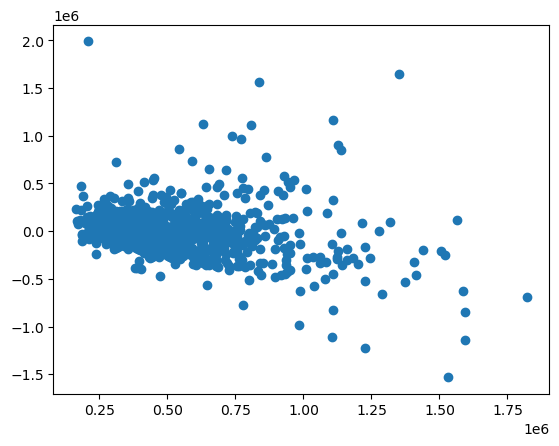

In [11]:
import matplotlib.pyplot as plt
plt.scatter(x=y_pred, y=residuals);
# It seems that as the actual house price goes up, predicted value goes up more than expected.

## Submit your assignment, or explore further
You can submit your assignment now to receive a grade from the system. There is some optional material below demonstrating two other regression algorithms that are not graded.

### 5. Bonus Material (Optional)
#### Step 5.1: Experiment with a Different Regression Algorithm
Examine the results with different regression algorithms (e.g., `DecisionTreeRegressor` or `RandomForestRegressor`) and compare its performance to the Linear Regression model using the same evaluation metrics.

The `random_state` variable is set to 42 to ensure reproducability and ensure the same results are obtained as the previous part of the assignment.

In [12]:
from sklearn.tree import DecisionTreeRegressor

tree = DecisionTreeRegressor(random_state=42)
tree.fit(X_train, y_train)
tree_pred = tree.predict(X_test)

tree_mse = mean_squared_error(y_test, tree_pred)
tree_r2 = r2_score(y_test, tree_pred)
tree_mae = mean_absolute_error(y_test, tree_pred)

print(f"DecisionTreeRegressor MSE: {tree_mse}")
print(f"DecisionTreeRegressor R-squared: {tree_r2}")
print(f"DecisionTreeRegressor MAE: {tree_mae}")

DecisionTreeRegressor MSE: 142251248392.3059
DecisionTreeRegressor R-squared: -0.35690031472365025
DecisionTreeRegressor MAE: 239170.55205692578


In [13]:
from sklearn.ensemble import RandomForestRegressor

forest = RandomForestRegressor(random_state=42)
forest.fit(X_train, y_train)
forest_pred = forest.predict(X_test)

forest_mse = mean_squared_error(y_test, forest_pred)
forest_r2 = r2_score(y_test, forest_pred)
forest_mae = mean_absolute_error(y_test, forest_pred)

print(f"RandomForestRegressor MSE: {forest_mse}")
print(f"RandomForestRegressor R-squared: {forest_r2}")
print(f"RandomForestRegressor MAE: {forest_mae}")

RandomForestRegressor MSE: 91427995620.68578
RandomForestRegressor R-squared: 0.12789042321704414
RandomForestRegressor MAE: 196501.64566259907
